In [2]:
import numpy as np
import pandas as pd
import statsmodels.api as sm
from statsmodels.formula.api import ols

import seaborn as sns
from matplotlib import pyplot as plt

# fig3a

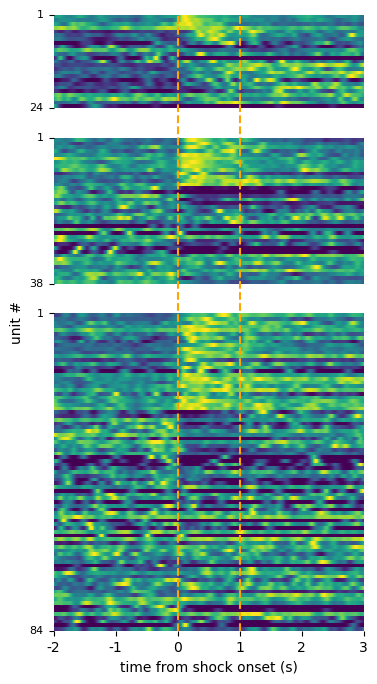

In [3]:
df_sum = pd.read_parquet("SuppFig3a.parquet")

gap   = 8
count = 0

rates_int  = []
units_N    = []
units_idx  = []

for po in ['dorsal', 'intermediate', 'ventral']:
    tmp = (df_sum
           .set_index(['rat', 'cluster'])
           .query("pole == '{}'".format(po))
           .sort_values('shocks_response'))

    t = np.array(tmp['time'].iloc[0])

    rates_int.append(np.nan_to_num(np.vstack([r / np.max(r) for r in tmp['rates_shocks']])))
    rates_int.append(np.full((gap, len(t)), np.nan))
    units_N.append([1, len(tmp) - 1])
    units_idx.append([count, count + len(tmp)])
    count += len(tmp) + gap

fig, ax = plt.subplots(1, 1, figsize=(4, 8))
sns.heatmap(np.vstack(rates_int)[:-gap], cmap='viridis', cbar=None, ax=ax)

xlabels = [-2, -1, 0, 1, 2, 3]
xticks  = np.array([np.argmin(np.abs(t - ts)) for ts in xlabels])

ax.axvline(np.argmin(np.abs(t)),     color='orange', ls='--')
ax.axvline(np.argmin(np.abs(t - 1)), color='orange', ls='--')

ax.set(xlim=(xticks[0], xticks[-1]),
       ylabel='unit #', xlabel='time from shock onset (s)')
ax.set_xticks(xticks)
ax.set_xticklabels(xlabels, rotation=0)
ax.set_yticks(np.concatenate(units_idx))
ax.set_yticklabels(np.concatenate(units_N), rotation=0)
ax.tick_params(axis='y', labelsize=8)

# fig2c

/home/michon/.conda/envs/analysis/lib/python3.10/site-packages/statsmodels/regression/mixed_linear_model.py:2237: ConvergenceWarning: The MLE may be on the boundary of the parameter space.
  warnings.warn(msg, ConvergenceWarning)
/home/michon/.conda/envs/analysis/lib/python3.10/site-packages/statsmodels/regression/mixed_linear_model.py:2237: ConvergenceWarning: The MLE may be on the boundary of the parameter space.
  warnings.warn(msg, ConvergenceWarning)



--- dorsal hippocampus ---
                   0        1                    2                3
0             Model:  MixedLM  Dependent Variable:  rate_delta_corr
1  No. Observations:     1389              Method:             REML
2        No. Groups:        1               Scale:           0.0082
3   Min. group size:     1389      Log-Likelihood:        1334.1002
4   Max. group size:     1389           Converged:              Yes
5   Mean group size:   1389.0                                      
                                                                         Coef. Std.Err.       z  P>|z|  [0.025 0.975]
Intercept                                                               -0.026    0.020  -1.332  0.183  -0.065  0.012
C(stimulus)[T.shock]                                                    -0.006    0.021  -0.304  0.761  -0.046  0.034
context_learning[T.RECALLER]                                             0.018    0.022   0.822  0.411  -0.025  0.060
C(stimulus)[T.shock]:con

/home/michon/.conda/envs/analysis/lib/python3.10/site-packages/statsmodels/regression/mixed_linear_model.py:2237: ConvergenceWarning: The MLE may be on the boundary of the parameter space.
  warnings.warn(msg, ConvergenceWarning)


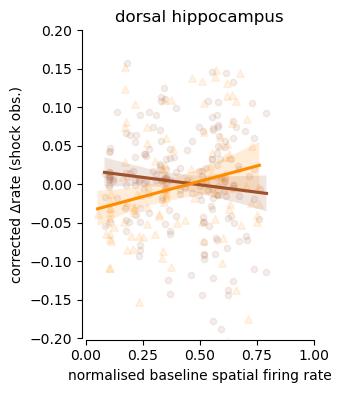

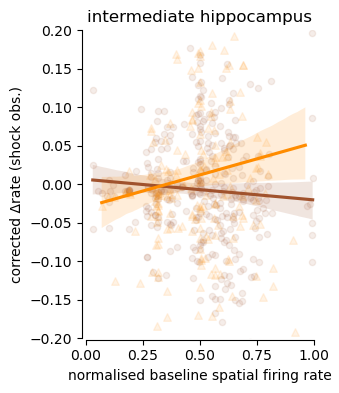

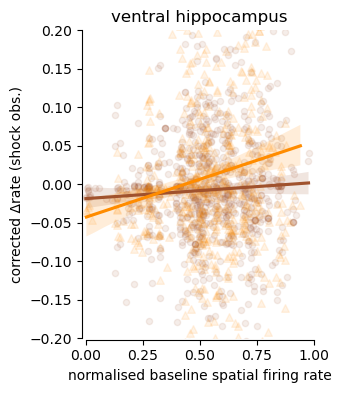

In [5]:
df = pd.read_parquet('SuppFig3b.parquet')


for po in ['dorsal', 'intermediate', 'ventral']:
    tmp_model = df.query("pole == '{}'".format(po))

    fig, ax = plt.subplots(1, 1, figsize=(3, 4))

    sns.regplot(x='base_place_rate_post', y='rate_delta_corr',
                data=tmp_model.query("stimulus == 'noshock'"),
                ci=95, marker='.', scatter_kws={'alpha': 0.1, 's': 80},
                color='sienna', label='control moments', ax=ax)
    sns.regplot(x='base_place_rate_post', y='rate_delta_corr',
                data=tmp_model.query("stimulus == 'shock'"),
                ci=95, marker='^', scatter_kws={'alpha': 0.1, 's': 30},
                color='darkorange', label='shock observation', ax=ax)

    ax.set(xlim=(-0.01, 1.01), ylim=(-0.2, 0.2),
           xlabel='normalised baseline spatial firing rate',
           ylabel=u'corrected Δrate (shock obs.)',
           title='{} hippocampus'.format(po))
    sns.despine(offset=True, trim=True)

stats = []

for pole in ['dorsal', 'intermediate', 'ventral']:
    tmp_model = df.query("pole == '{}'".format(po))
    tmp_model = tmp_model.replace({'not learned': 'NON-RECALLER', 'learned': 'RECALLER'})
    tmp_model['response'] = ['ShockObs+' if r == 'excited' else 'rest'
                              for r in tmp_model.shocks_response]
    tmp_model['response'] = (tmp_model['response']
                              .astype('category')
                              .cat.reorder_categories(['rest', 'ShockObs+']))

    fixed_formula = "rate_delta_corr ~ base_place_rate_post * C(stimulus) * context_learning"
    vc_formula    = {'rat': 'C(rat)'}
    oo = np.ones(tmp_model.shape[0])

    model   = sm.MixedLM.from_formula(fixed_formula, data=tmp_model,
                                       groups=oo, vc_formula=vc_formula)
    results = model.fit()
    summ    = results.summary()

    stats.append("")
    stats.append("--- {} hippocampus ---".format(pole))
    stats.append(summ.tables[0].to_string())
    stats.append(summ.tables[1].to_string())

for line in stats:
    print(line)